In [332]:
%autosave 60

Autosaving every 60 seconds


Датасет взять с kaggle: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors

In [333]:
# Подключим нужные для базовых операций библиотеки
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

# Подключим пакеты для использования OLS метода и тестов
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
from scipy.stats import boxcox

import math

# Подгрузим полезные функции
from my_utils import *

In [334]:
df = pd.read_csv("StudentPerformanceFactors.csv")

# Первичный анализ данных
print("Структура данных:\n", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [335]:
print("Описание данных:\n", df.describe())

Описание данных:
        Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000   6607.00000      6607.000000   
mean       19.975329    79.977448      7.02906        75.070531   
std         5.990594    11.547475      1.46812        14.399784   
min         1.000000    60.000000      4.00000        50.000000   
25%        16.000000    70.000000      6.00000        63.000000   
50%        20.000000    80.000000      7.00000        75.000000   
75%        24.000000    90.000000      8.00000        88.000000   
max        44.000000   100.000000     10.00000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6607.000000        6607.000000  6607.000000  
mean            1.493719           2.967610    67.235659  
std             1.230570           1.031231     3.890456  
min             0.000000           0.000000    55.000000  
25%             1.000000           2.000000    65.000000  
50%             1.000000

In [336]:
# Проверка пропусков и выбросов
print("Пропущенные значения:\n", df.isnull().sum())

Пропущенные значения:
 Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


Датасет достаточно большой поэтому просто удалим строчки с пропусками.

In [337]:
# Удаление пропущенных значений
df = df.dropna()

C:\Users\krasn\AppData\Local\Temp\ipykernel_96520\3799515773.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='hsv', alpha=0.5)
C:\Users\krasn\AppData\Local\Temp\ipykernel_96520\3799515773.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='hsv', alpha=0.5)
C:\Users\krasn\AppData\Local\Temp\ipykernel_96520\3799515773.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='hsv', alpha=0.5)


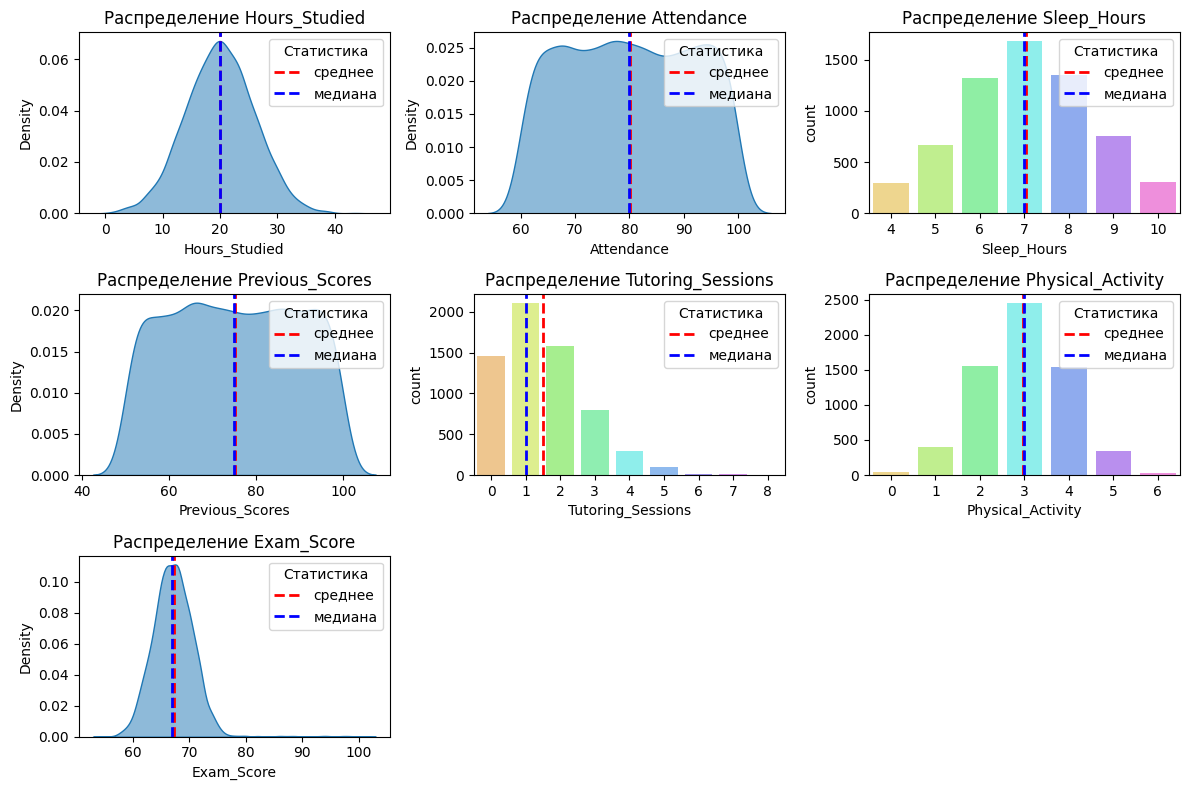

In [338]:
categorical_features = ["Parental_Involvement", "Access_to_Resources", "Extracurricular_Activities", "Motivation_Level", "Internet_Access", "Family_Income", "School_Type", "Peer_Influence", "Teacher_Quality", "Learning_Disabilities", "Distance_from_Home", "Parental_Education_Level", "Gender"]
numeric_features = ["Hours_Studied", "Attendance", "Sleep_Hours", "Previous_Scores", "Tutoring_Sessions", "Physical_Activity", "Exam_Score"]
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_features):
    plt.subplot(3, 3, i+1)
    if df[col].nunique() < 10:
        sns.countplot(x=col, data=df, palette='hsv', alpha=0.5)
    else:
        sns.kdeplot(df[col], fill=True, alpha=0.5)
    plt.title(f'Распределение {col}')
    # Подправка для Sleep_Hours, медиана и среднее были сдвинуты на графике, скорее всего, это из-за того, что значения начинались не с нуля.
    if col == 'Sleep_Hours':
        plt.axvline(df['Sleep_Hours'].mean()-4, color='red', linestyle='dashed', linewidth=2, label='среднее')
        plt.axvline(df['Sleep_Hours'].median()-4, color='blue', linestyle='dashed', linewidth=2, label='медиана')
    else:
        plt.axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=2, label='среднее')
        plt.axvline(df[col].median(), color='blue', linestyle='dashed', linewidth=2, label='медиана')
    plt.legend(loc='upper right', title='Статистика')
plt.tight_layout()
plt.show()

**Выводы по распределениям:**

Факторы: Часы обучения (Hours_Studied), Часы сна (Sleep_Hours), Физическая активность (Physical_Activity) - нормально распределены.

Посещаемость (Attendance), Предыдущие оценки (Previous_Scores) - равномерно распределены.

Количество занятий с репетитором (Tutoring_Sessions) - похоже на логнормальное распределение.

Итоговый балл за экзамен (Exam_Score) близко к нормальному, но имеется очень длинный хвост учеников, набравших больше 80. Для последующегося анализа их можно будет оставить, но для решения задачи регрессионного анализа придется что-то сделать: либо выкинуть как выбросы, либо преобразовать значения.

C:\Users\krasn\AppData\Local\Temp\ipykernel_96520\3468762751.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=group_by, y=feature, palette="husl", width=0.6, showcaps=True,
C:\Users\krasn\AppData\Local\Temp\ipykernel_96520\3468762751.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=group_by, y=feature, palette="husl", width=0.6, showcaps=True,
C:\Users\krasn\AppData\Local\Temp\ipykernel_96520\3468762751.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=group_by, y=feature, palette="husl", width=0.6, s

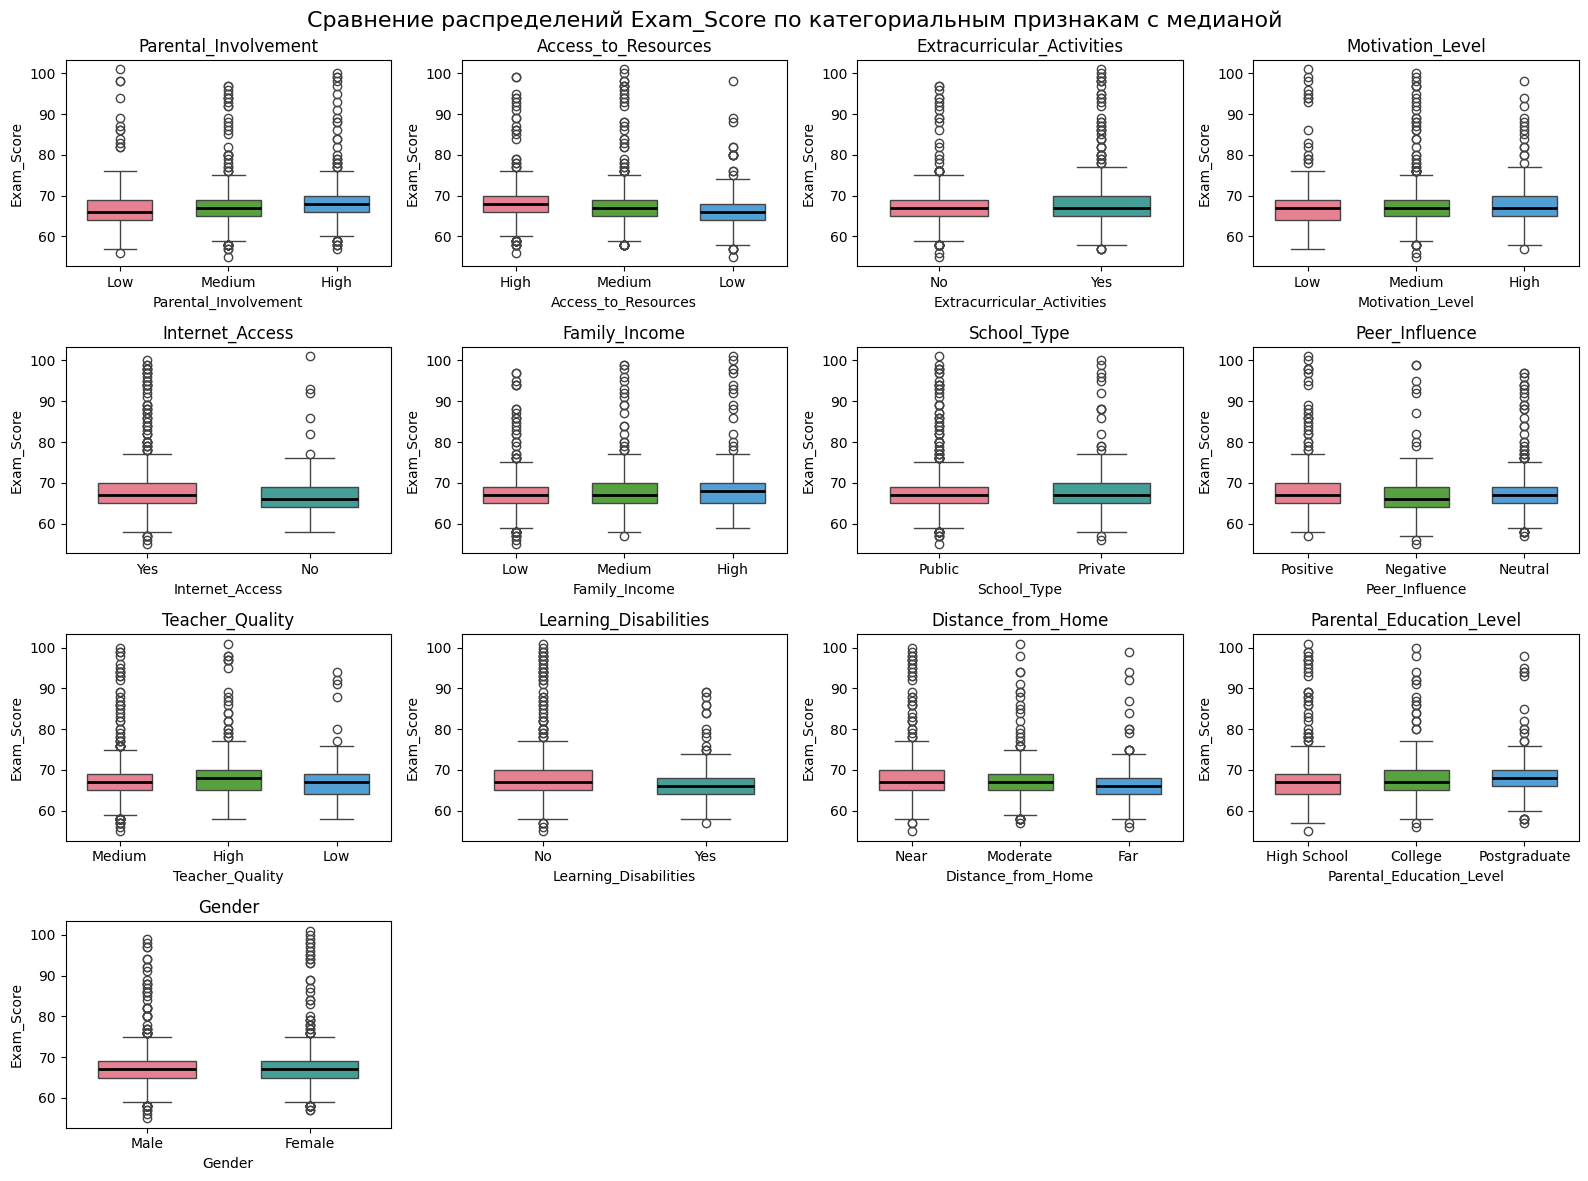

In [339]:
# Сравнение распределений по группам
def compare_distributions(df, feature, group_by):
    # plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=group_by, y=feature, palette="husl", width=0.6, showcaps=True, 
                    #  showmeans=True,
                    #  meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black", "markersize":"8"},
                     medianprops={"color": "black", "linewidth": 2})
    
    plt.title(f'{group_by}')
    plt.xlabel(group_by)
    plt.ylabel(feature)
    # plt.show()

plt.figure(figsize=(16, 12))
plt.suptitle("Сравнение распределений Exam_Score по категориальным признакам c медианой", fontsize=16)
for i, col in enumerate(categorical_features):
    plt.subplot(4, 4, i+1)
    compare_distributions(df, 'Exam_Score', col)

plt.tight_layout()
plt.show()

#### По графикам можно сделать несколько ключевых выводов:

##### Факторы с сильным влиянием на Exam_Score:

- Parental_Involvement, Access_to_Resources, Family_Income, Motivation_Level, Teacher_Quality, Parental_Education_Level – чем выше их уровень, тем лучше результаты экзамена.
- Internet_Access – наличие интернета положительно влияет на успеваемость.
##### Отрицательное влияние:

- Learning_Disabilities – ученики с нарушениями обучения в среднем показывают более низкие результаты.
Distance_from_Home – чем дальше ученик живёт от школы, тем ниже его баллы.
##### Неоднозначные факторы:

- School_Type (Public vs Private) – распределения сильно пересекаются, разница незначительна.
- Peer_Influence – положительное влияние сверстников не даёт явного преимущества в баллах.
- Gender - пол никак не влияет на результат экзамена

## Гипотезы

### Гипотеза 1
- $H_0$: Распределения баллов на итоговом экзамене(`Exam_Score`), одинаковы для двух сегментов: учеников из обычных школ(`public`) и из частных школ (`private`).
- $H_1$: Распределения различаются.


In [340]:
from scipy.stats import mannwhitneyu
group1 = df[df['School_Type'] == 'Public']['Exam_Score']
group2 = df[df['School_Type'] == 'Private']['Exam_Score']

_, mw_pvalue = mannwhitneyu(group1, group2)
print(f"Mann-Whitneyu: p-value={mw_pvalue}")

Mann-Whitneyu: p-value=0.25199483544916346


**Вывод:** Гипотеза $H_0$ **не отвергается**. Значит влияние на успеваемость учеников от типа школы нет или оно незначительное.

### Гипотеза 2
- $H_0$: Нет разницы в средних баллах на итоговом экзамене(`Exam_Score`) между учениками с разным уровнем дохода семьи.
- $H_1$: Распределения различаются.

In [341]:
def bootstrap_mean_diff(sample1, sample2, num_iterations=10000):
    boot_diffs = []
    for _ in range(num_iterations):
        boot_s1 = np.random.choice(sample1, size=len(sample1), replace=True)
        boot_s2 = np.random.choice(sample2, size=len(sample2), replace=True)
        boot_diffs.append(np.mean(boot_s1) - np.mean(boot_s2))
    lower = np.percentile(boot_diffs, 2.5)
    upper = np.percentile(boot_diffs, 97.5)
    return lower, upper


for group_a, group_b in [("Low", "Medium"), ("Low", "High"), ("Medium", "High")]:
    sample1 = df[df['Family_Income'] == group_a]['Exam_Score']
    sample2 = df[df['Family_Income'] == group_b]['Exam_Score']
    mean_diff = np.mean(sample1) - np.mean(sample2)
    lower, upper = bootstrap_mean_diff(sample1, sample2)
    print(f"Разность средних ({group_a} vs {group_b}): {mean_diff:.2f}")
    print(f"95% доверительный интервал для оценки среднего ({group_a} vs {group_b}): [{lower:.2f}, {upper:.2f}]")


Разность средних (Low vs Medium): -0.52
95% доверительный интервал для оценки среднего (Low vs Medium): [-0.73, -0.31]
Разность средних (Low vs High): -0.99
95% доверительный интервал для оценки среднего (Low vs High): [-1.27, -0.71]
Разность средних (Medium vs High): -0.47
95% доверительный интервал для оценки среднего (Medium vs High): [-0.75, -0.20]


**Вывод:** $H_0$ отвергается. Получилось, что чем ниже доход, тем ниже результат на экзамене. 

Почему это так?
#### 1. **Недостаток ресурсов для подготовки**

**Проблема:** 
Студенты с низким доходом могут иметь ограниченный доступ к платным образовательным материалам, репетиторам, курсам или даже стабильному интернету для онлайн-обучения.

**Эсперимент:** 
- Предоставить бесплатные учебные ресурсы (курсы, учебники, конспекты) студентам с низким доходом. 
- Организовать программу менторства со студентами для дополнительной поддержки.

#### 2. **Работа и нехватка времени на подготовку**

**Проблема:** 
Студенты с низким доходом могут работать параллельно с учёбой, что снижает время, доступное для подготовки к экзаменам.

**Эсперимет:**
- Дать возможность проходить тесты или дополнительные занятия в удобное время.
- Внедрение формата микро-обучения (короткие интерактивные уроки, которые можно изучать на ходу).
- Доступ к тайм-менеджменту и методикам эффективной учёбы.

#### Следующие шаги  
1. Провести эксперименты и собрать данные.  
2. Оценить влияние внедрённых решений на успеваемость.  
3. Определить наиболее эффективные меры и масштабировать их. 


### Гипотеза
- $H_0$: Нет разницы в среднем количестве сна(`Sleep_Hours`) между учениками с разной дальностью до школы(`Distance_from_Home`).
- $H_1$: Распределения различаются.


In [342]:
for group_a, group_b in [("Near", "Moderate"), ("Near", "Far"), ("Moderate", "Far")]:
    sample1 = df[df['Distance_from_Home'] == group_a]['Sleep_Hours']
    sample2 = df[df['Distance_from_Home'] == group_b]['Sleep_Hours']
    mean_diff = np.mean(sample1) - np.mean(sample2)
    lower, upper = bootstrap_mean_diff(sample1, sample2)
    print(f"Разность средних ({group_a} vs {group_b}): {mean_diff:.2f}")
    print(f"95% доверительный интервал для оценки среднего ({group_a} vs {group_b}): [{lower:.2f}, {upper:.2f}]")

Разность средних (Near vs Moderate): -0.02
95% доверительный интервал для оценки среднего (Near vs Moderate): [-0.10, 0.06]
Разность средних (Near vs Far): 0.02
95% доверительный интервал для оценки среднего (Near vs Far): [-0.10, 0.14]
Разность средних (Moderate vs Far): 0.04
95% доверительный интервал для оценки среднего (Moderate vs Far): [-0.09, 0.18]


**Выводы:** $H_0$ не отвергается. Следовательно, дальность до школы в среднем не влияет на длительность.

## Регрессионный анализ


Для начала надо закодировать категориальные переменный. Нам повезло, у признаков либо 2 значения, либо 3 значения, но про которые можно сказать, что больше, а что меньше. Поэтому мы кодируем либо $[0, 1]$, либо $[0, 0.5, 1]$.

In [343]:
# Кодирование категориальных переменных
df["Parental_Involvement"] = df["Parental_Involvement"].map({"Low": 0, "Medium": 0.5, "High": 1})
df["Access_to_Resources"] = df["Access_to_Resources"].map({"Low": 0, "Medium": 0.5, "High": 1})
df["Extracurricular_Activities"] = df["Extracurricular_Activities"].map({"No": 0, "Yes": 1})
df["Motivation_Level"] = df["Motivation_Level"].map({"Low": 0, "Medium": 0.5, "High": 1})
df["Internet_Access"] = df["Internet_Access"].map({"No": 0, "Yes": 1})
df["Family_Income"] = df["Family_Income"].map({"Low": 0, "Medium": 0.5, "High": 1})
df["School_Type"] = df["School_Type"].map({"Public": 0, "Private": 1})
df["Peer_Influence"] = df["Peer_Influence"].map({"Negative": 0, "Neutral": 0.5, "Positive": 1})
df["Teacher_Quality"] = df["Teacher_Quality"].map({"Low": 0, "Medium": 0.5, "High": 1})
df["Learning_Disabilities"] = df["Learning_Disabilities"].map({"No": 0, "Yes": 1})
df["Distance_from_Home"] = df["Distance_from_Home"].map({"Near": 0, "Moderate": 0.5, "Far": 1})
df["Parental_Education_Level"] = df["Parental_Education_Level"].map({"High School": 0, "College": 0.5, "Postgraduate": 1})
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

# массив названий признаков
X = df.columns.copy().drop("Exam_Score")
y = 'Exam_Score'

In [344]:
print(X)

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender'],
      dtype='object')


In [ ]:
def print_EDA(df, y, X):# Построим графики распределения и зависимости между таргетом и факторами
    for feat in X:

        if len(df[feat].unique()) < 5:
            continue
        # Отрисуем распределения нужных нам факторов
        if len(df[feat].unique()) < 10:
            sns.displot(df[feat], bins=(df[feat].max()-df[feat].min()), kde=True, kde_kws={'bw_adjust': 2})
        else:
            sb.displot(df[feat], bins=int(df[feat].max()-df[feat].min()/2), kde=True)
        plt.xlabel(f'{feat} values')
        plt.ylabel(f'{feat} freq')
        plt.title(f'{feat} histogram and density plot')
        plt.show()

        # Также отрисуем зависимость между таргетом и интересующими факторами
        sb.scatterplot(data=df, x=feat, y=y)
        plt.xlabel(f'{feat} values')
        plt.ylabel(f'{y} values')
        plt.title(f'{y} vs {feat} distribution')
        plt.show()

    sb.displot(df[y], bins=20, kde=True)
    plt.xlabel(f'{y} values')
    plt.ylabel(f'{y} freq')
    plt.title(f'{y} histogram and density plot')
    plt.show()

    # Построение boxplot для Exam_Score
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df["Exam_Score"], color="skyblue")
    plt.title("Boxplot для Exam_Score")
    plt.ylabel("Exam Score")
    plt.show()


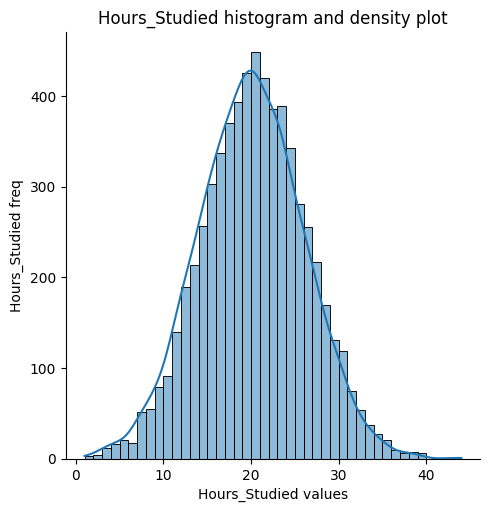

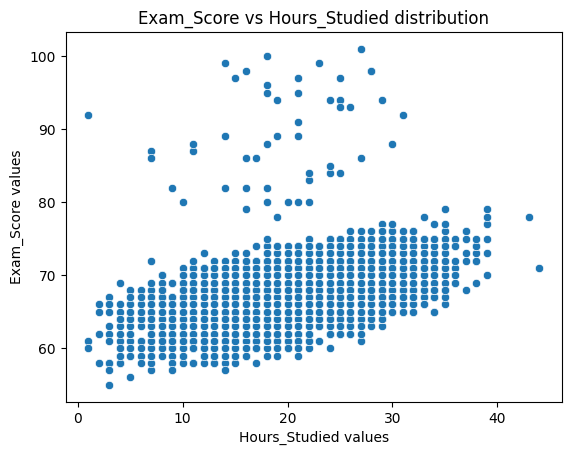

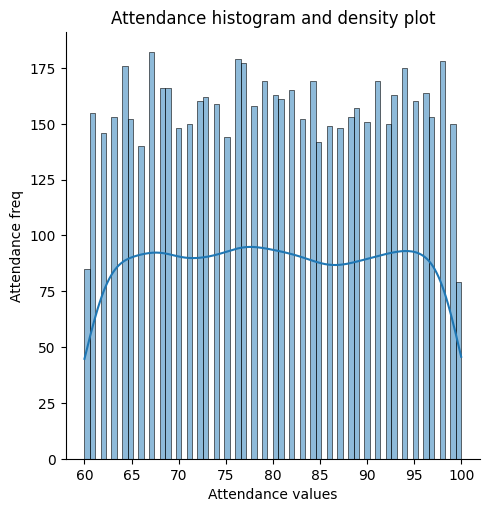

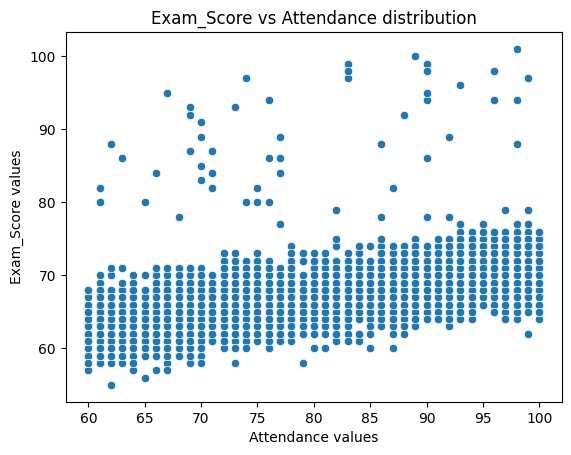

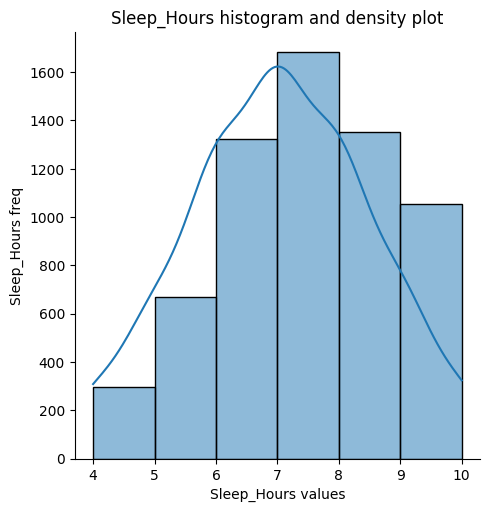

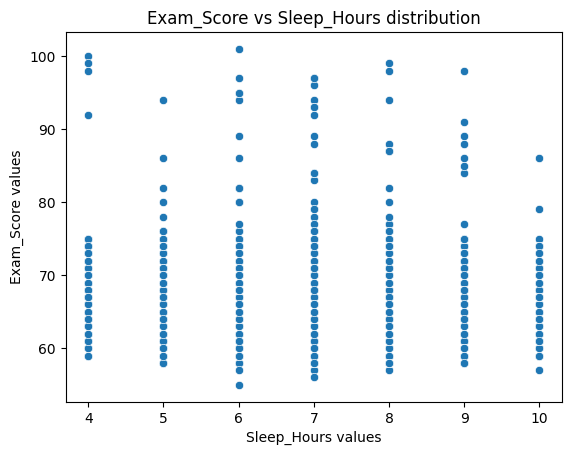

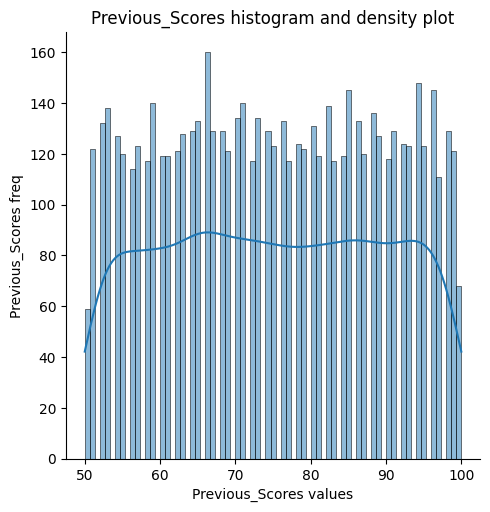

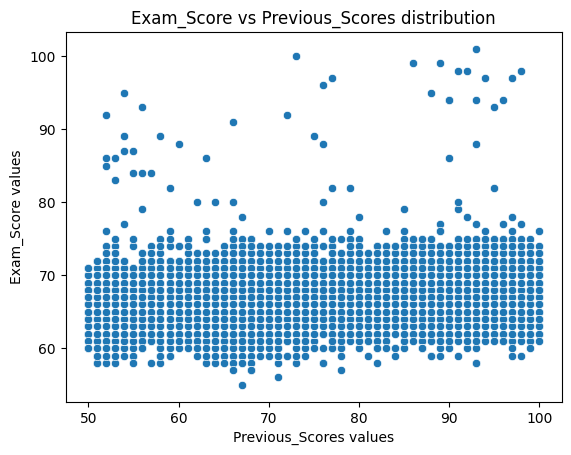

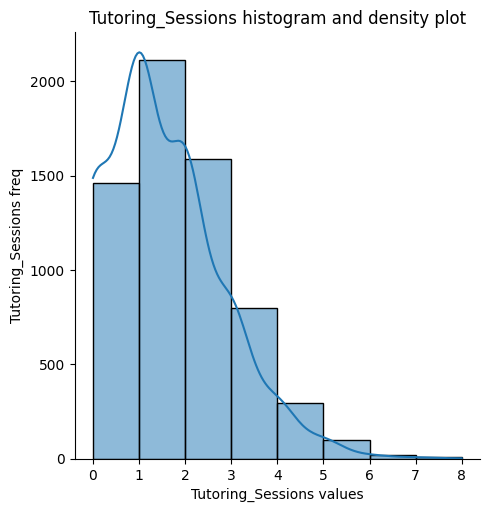

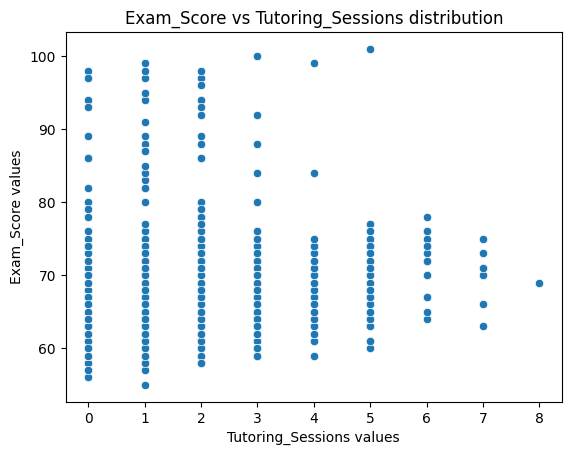

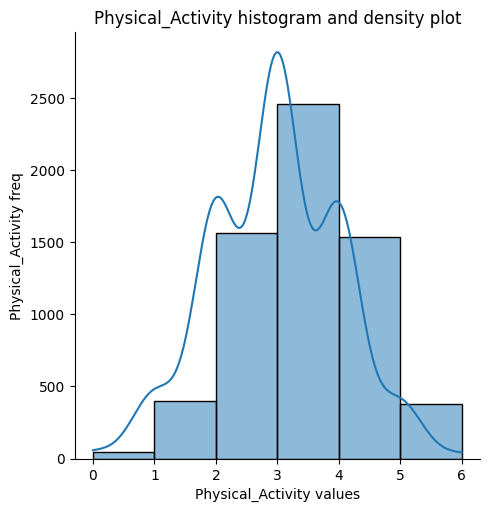

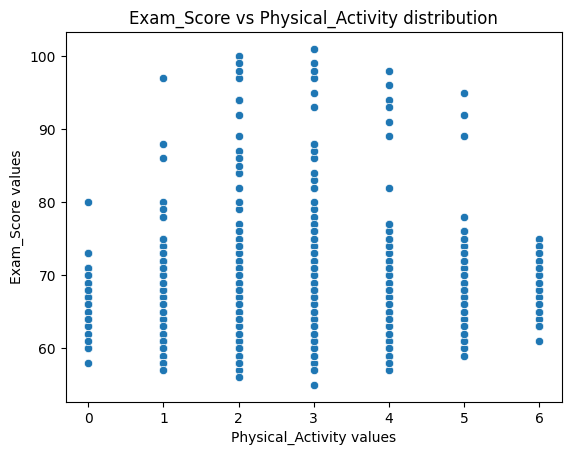

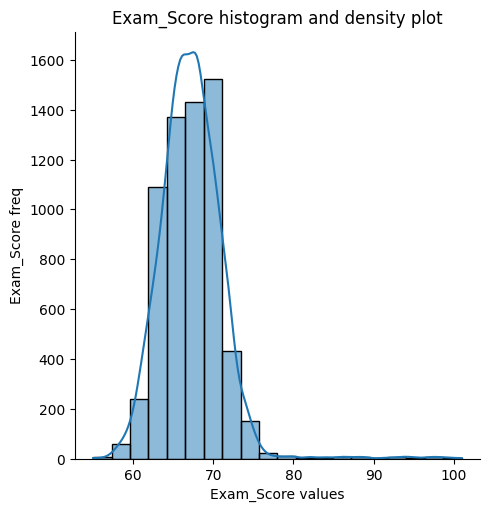

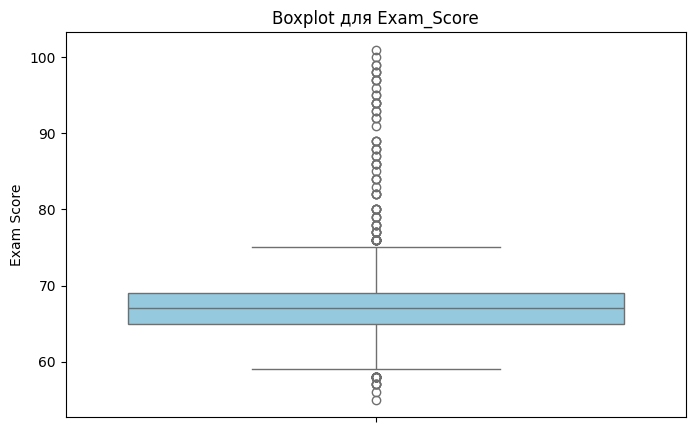

In [346]:
print_EDA(df, y, X)

**Выводы по EDA:**
- На графиках оценки за итоговый экзамен примерно **больше 78** выглядят как выбросы. Их стоит удалить.

- Также под подозрением также значения **меньше 55**, их можно удалить, так как данных много. 

- Гистограмма `Tutoring_Sessions` и `Exam_Score` показывают **асимметричное распределение** с длинным правым хвостом. Это может **искажать результаты линейных моделей** и увеличивать влияние редких значений. Поэтому необходимо его нормализовать.


In [347]:
df = df[(df['Exam_Score'] < 78) & (df['Exam_Score']>55)]
df['Tutoring_Sessions'] , lambda_val_tutor = boxcox(df["Tutoring_Sessions"] + 1)
df['Exam_Score'] , lambda_val_exam = boxcox(df["Exam_Score"] + 1)
print(f"lambda tutor: {lambda_val_exam}, lambda exam: {lambda_val_exam}")


lambda tutor: 1.0888264051235783, lambda exam: 1.0888264051235783


In [348]:
def plot_data(dataset, target, feature_names):
    # Графики для проверки предпосылок Гаусса-Маркова
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))

    # 1. График остатков vs предсказанных значений (проверка гомоскедастичности)
    axes[0, 0].scatter(dataset[f'{target}_hat'], dataset['residuals_std'], alpha=0.5)
    axes[0, 0].axhline(0, color='red', linestyle='--')
    axes[0, 0].set_xlabel('Предсказанные значения')
    axes[0, 0].set_ylabel('Нормированные остатки')
    axes[0, 0].set_title('График остатков vs предсказанных значений')

    # 2. Гистограмма остатков (проверка нормальности)
    sns.histplot(dataset['residuals_std'], kde=True, ax=axes[0, 1])
    axes[0, 1].set_title('Гистограмма нормированных остатков')

    # 3. QQ-график (проверка нормальности)
    sm.qqplot(dataset['residuals_std'], line='45', ax=axes[1, 0])
    axes[1, 0].set_title('QQ-график нормированных остатков')

    # 4. Автокорреляция остатков
    residuals = dataset['residuals_std']
    lagged_residuals = np.roll(residuals, 1)  # Смещенные на 1 шаг остатки

    axes[1, 1].scatter(lagged_residuals[1:], residuals[1:], edgecolor='black')

    # Добавление осей X и Y
    axes[1, 1].axhline(0, color='blue', linewidth=2)
    axes[1, 1].axvline(0, color='blue', linewidth=2)

    # Подписи осей
    axes[1, 1].set_xlabel("(i-1) остаток", fontsize=12)
    axes[1, 1].set_ylabel("i-й остаток", fontsize=12)
    axes[1, 1].set_title("Отсутствие автокорреляции в остатках", fontsize=14)

    plt.tight_layout()
    plt.show()

    # Проверим наличие мультиколлинеарности
    plt.figure(figsize=(16, 12))

    corr_matrix = df.corr(numeric_only=True)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
    sns.heatmap(corr_matrix, annot=True, mask=mask, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, square=True, cbar=True)

    plt.title("Матрица корреляций")
    plt.show()

    # Проверка мультиколлинеарности
    vif_data = pd.DataFrame()
    vif_data["Feature"] = feature_names
    vif_data["VIF"] = [variance_inflation_factor(dataset.values, i) for i in range(len(feature_names))]
    print(f'Проверка на мультиколлинеарности:')
    print(vif_data)

In [349]:
# Функция анализа распределения остатков.
# Источник: https://github.com/AANazarov/MyModulePython/blob/master/my_module__stat.py
def norm_distr_check (
        data,
        p_level:    float = 0.95):

    """
    Проверка нормальности распределения: возвращает DataFrame, содержащий 
    результаты проверки нормальности распределения с использованием различных
    тестов.
    

    Args:
        data:                                     
            исходный массив данных.
            
        p_level (float, optional):           
            доверительная вероятность. 
            Defaults to 0.95.

    Returns:
        result (pd.core.frame.DataFrame):
            результат 
    
    Notes:
        1. Функция реализует следующие тесты:
            - тест Шапиро-Уилка (Shapiro-Wilk test) (при 8 <= N <= 1000)
            - тест Эппса-Палли (Epps_Pulley_test) (при N >= 8)
            - тест Д'Агостино (K2-test)
            - тест Андерсона-Дарлинга (Anderson-Darling test)
            - тест Колмогорова-Смирнова (Kolmogorov-Smirnov test) (при N >= 50)
            - тест Лиллиефорса (Lilliefors’ test)
            - тест Крамера-Мизеса-Смирнова (Cramér-von Mises test) (при N >= 40)
            - тест Пирсона (хи-квадрат) (chi-square test) (при N >= 100)
            - тест Харке-Бера (Jarque-Bera tes) (при N >= 2000)
            - тест асимметрии (при N >= 8)
            - тест эксцесса (при N >= 20)            
            
        2. Функция требует наличия файла table\Epps_Pulley_test_table.csv, 
            который содержит табличные значения критерия Эппса-Палли.
            
    """    
    
    a_level = 1 - p_level
    X = np.array(data)
    N = len(X)
       
    # тест Шапиро-Уилка (Shapiro-Wilk test)
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html
    if N >= 8:
        result_ShW = sci.stats.shapiro(X)
        s_calc_ShW = result_ShW.statistic
        a_calc_ShW = result_ShW.pvalue
        conclusion_ShW = 'gaussian distribution' if a_calc_ShW >= a_level \
            else 'not gaussian distribution'
    else:
        result_ShW = '-'
        s_calc_ShW = '-'
        a_calc_ShW = '-'
        conclusion_ShW = 'count less than 8'

    # тест Эппса-Палли (Epps_Pulley_test)
    сdf_beta_I = lambda x, a, b: sci.stats.beta.cdf(x, a, b, loc=0, scale=1)
    g_beta_III = lambda z, δ: δ*z / (1+(δ-1)*z)
    cdf_beta_III = \
        lambda x, θ0, θ1, θ2, θ3, θ4: \
            сdf_beta_I(g_beta_III((x - θ4)/θ3, θ2), θ0, θ1)
    
    θ_1 = (1.8645, 2.5155, 5.8256, 0.9216, 0.0008)    # для 15 < n < 50
    θ_2 = (1.7669, 2.1668, 6.7594, 0.91, 0.0016)    # для n >= 50
    
    if N >= 8 and N <= 1000:
        X_mean = X.mean()
        m2 = np.var(X, ddof = 0)
        # расчетное значение статистики критерия
        A = np.sqrt(2) * np.sum([np.exp(-(X[i] - X_mean)**2 / (4*m2)) 
                              for i in range(N)])
        B = 2/N * np.sum(
            [np.sum([np.exp(-(X[j] - X[k])**2 / (2*m2)) for j in range(0, k)]) 
             for k in range(1, N)])
        s_calc_EP = 1 + N / np.sqrt(3) + B - A
        # табличное значение статистики критерия
        Tep_table_df = pd.read_csv(
            filepath_or_buffer='table/Epps_Pulley_test_table.csv',
            sep=';',
            index_col='n')
        p_level_dict = {
            0.9:   Tep_table_df.columns[0],
            0.95:  Tep_table_df.columns[1],
            0.975: Tep_table_df.columns[2],
            0.99:  Tep_table_df.columns[3]}
        f_lin = sci.interpolate.interp1d(Tep_table_df.index, \
                                         Tep_table_df[p_level_dict[p_level]])
        critical_value_EP = float(f_lin(N))
        # проверка гипотезы
        if 15 < N < 50:
            a_calc_EP = 1 - cdf_beta_III(s_calc_EP, θ_1[0], θ_1[1], \
                                         θ_1[2], θ_1[3], θ_1[4])
            conclusion_EP = 'gaussian distribution' if a_calc_EP > a_level \
                else 'not gaussian distribution'            
        elif N >= 50:
            a_calc_EP = 1 - cdf_beta_III(s_calc_EP, θ_2[0], θ_2[1], \
                                         θ_2[2], θ_2[3], θ_2[4])
            conclusion_EP = 'gaussian distribution' if a_calc_EP > a_level \
                else 'not gaussian distribution'            
        else:
            a_calc_EP = ''              
            conclusion_EP = 'gaussian distribution' \
                if s_calc_EP <= critical_value_EP \
                    else 'not gaussian distribution'            
                
    elif N > 1000:
        s_calc_EP = '-'
        critical_value_EP = '-'
        a_calc_EP = '-'
        conclusion_EP = 'count more than 1000'
    else:
        s_calc_EP = '-'
        critical_value_EP = '-'
        a_calc_EP = '-'
        conclusion_EP = 'count less than 8'
    
    
    # тест Д'Агостино (K2-test)
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.normaltest.html
    if N >= 8:
        result_K2 = sci.stats.normaltest(X)
        s_calc_K2 = result_K2.statistic
        a_calc_K2 = result_K2.pvalue
        conclusion_K2 = 'gaussian distribution' if a_calc_K2 >= a_level \
            else 'not gaussian distribution'
    else:
        s_calc_K2 = '-'
        a_calc_K2 = '-'
        conclusion_K2 = 'count less than 8'
    
    # тест Андерсона-Дарлинга (Anderson-Darling test)
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.anderson.html
    result_AD = sci.stats.anderson(X)
    df_AD = pd.DataFrame({
        'a_level (%)': result_AD.significance_level,
        'statistic': [result_AD.statistic 
                      for i in range(len(result_AD.critical_values))],
        'critical_value': result_AD.critical_values
        })
    statistic_AD = float(df_AD[df_AD['a_level (%)'] == round((1 - p_level)*100, 1)]['statistic'].iloc[0])
    critical_value_AD = float(df_AD[df_AD['a_level (%)'] == round((1 - p_level)*100, 1)]['critical_value'].iloc[0])
    conclusion_AD = 'gaussian distribution' \
        if statistic_AD < critical_value_AD else 'not gaussian distribution'
    
    # тест Колмогорова-Смирнова (Kolmogorov-Smirnov test)
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kstest.html#scipy.stats.kstest
    if N >= 50:
        result_KS = sci.stats.kstest(X, 'norm')
        s_calc_KS = result_KS.statistic
        a_calc_KS = result_KS.pvalue
        conclusion_KS = 'gaussian distribution' if a_calc_KS >= a_level \
            else 'not gaussian distribution'
    else:
        s_calc_KS = '-'
        a_calc_KS = '-'
        conclusion_KS = 'count less than 50'
        
    # тест Лиллиефорса (Lilliefors’ test)
    # https://www.statsmodels.org/dev/generated/statsmodels.stats.diagnostic.lilliefors.html
    from statsmodels.stats.diagnostic import lilliefors
    s_calc_L, a_calc_L = sm.stats.diagnostic.lilliefors(X, 'norm')
    conclusion_L = 'gaussian distribution' if a_calc_L >= a_level \
        else 'not gaussian distribution'  
    
    # тест Крамера-Мизеса-Смирнова (Cramér-von Mises test)
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.cramervonmises.html#scipy-stats-cramervonmises
    if N >= 40:
        result_CvM = sci.stats.cramervonmises(X, 'norm')
        s_calc_CvM = result_CvM.statistic
        a_calc_CvM = result_CvM.pvalue
        conclusion_CvM = 'gaussian distribution' if a_calc_CvM >= a_level \
            else 'not gaussian distribution'
    else:
        s_calc_CvM = '-'
        a_calc_CvM = '-'
        conclusion_CvM = 'count less than 40'
    
    # тест Пирсона (хи-квадрат) (chi-square test)
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chisquare.html#scipy-stats-chisquare
    if N >= 100:
        ddof = 2    # поправка к числу степеней свободы 
                    # (число параметров распределения, оцениваемое по выборке)
        result_Chi2 = sci.stats.chisquare(X, ddof=ddof)
        s_calc_Chi2 = result_Chi2.statistic
        a_calc_Chi2 = result_Chi2.pvalue
        conclusion_Chi2 = 'gaussian distribution' if a_calc_Chi2 >= a_level \
            else 'not gaussian distribution'
    else:
        s_calc_Chi2 = '-'
        a_calc_Chi2 = '-'
        conclusion_Chi2 = 'count less than 100'
        
    # тест Харке-Бера (асимметрии и эксцесса) (Jarque-Bera tes)
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.jarque_bera.html#scipy-stats-jarque-bera
    if N >= 2000:
        result_JB = sci.stats.jarque_bera(X)
        s_calc_JB = result_JB.statistic
        a_calc_JB = result_JB.pvalue
        conclusion_JB = 'gaussian distribution' if a_calc_JB >= a_level \
            else 'not gaussian distribution'
    else:
        s_calc_JB = '-'
        a_calc_JB = '-'
        conclusion_JB = 'count less than 2000'
    
    # тест асимметрии
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.skewtest.html#scipy-stats-skewtest
    if N >= 8:
        result_As = sci.stats.skewtest(X)
        s_calc_As = result_As.statistic
        a_calc_As = result_As.pvalue
        conclusion_As = 'gaussian distribution' if a_calc_As >= a_level \
            else 'not gaussian distribution'
    else:
        s_calc_As = '-'
        a_calc_As = '-'
        conclusion_As = 'count less than 8'
     
    # тест эксцесса
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosistest.html#scipy-stats-kurtosistest
    if N > 20:
        result_Es = sci.stats.kurtosistest(X)
        s_calc_Es = result_Es.statistic
        a_calc_Es = result_Es.pvalue
        conclusion_Es = 'gaussian distribution' if a_calc_Es >= a_level \
            else 'not gaussian distribution'
    else:
        s_calc_Es = '-'
        a_calc_Es = '-'
        conclusion_Es = 'count less than 20'
    
    # Создадим DataFrame для сводки результатов    
    result = pd.DataFrame({
    'test': (
        'Shapiro-Wilk test',
        'Epps-Pulley test',
        "D'Agostino's K-squared test",
        'Anderson-Darling test',
        'Kolmogorov–Smirnov test',
        'Lilliefors test',
        'Cramér–von Mises test',
        'Chi-squared test',
        'Jarque–Bera test',
        'skewtest',
        'kurtosistest'),
    'p_level': (p_level),
    'a_level': (a_level),
    'a_calc': (
        a_calc_ShW,
        a_calc_EP,
        a_calc_K2,
        '',
        a_calc_KS,
        a_calc_L,
        a_calc_CvM,
        a_calc_Chi2,
        a_calc_JB,
        a_calc_As,
        a_calc_Es),
    'a_calc >= a_level': (
        a_calc_ShW >= a_level if N >= 8 else '-',
        a_calc_EP >= a_level if N > 15 and N <= 1000 else '-',
        a_calc_K2 >= a_level if N >= 8 else '-',
        '',
        a_calc_KS >= a_level if N >= 50 else '-',
        a_calc_L >= a_level,
        a_calc_CvM >= a_level if N >= 40 else '-',
        a_calc_Chi2 >= a_level if N >= 100 else '-',
        a_calc_JB >= a_level if N >= 2000 else '-',
        a_calc_As >= a_level if N >= 8 else '-',
        a_calc_Es >= a_level if N > 20 else '-'),
    'statistic': (
        s_calc_ShW,
        s_calc_EP,
        s_calc_K2,
        statistic_AD,
        s_calc_KS,
        s_calc_L,
        s_calc_CvM,
        s_calc_Chi2,
        s_calc_JB,
        s_calc_As,
        s_calc_Es),
    'critical_value': (
        '',
        critical_value_EP,
        '',
        critical_value_AD,
        '', '', '', '', '', '', ''),
    'statistic < critical_value': (
        '',
        s_calc_EP < critical_value_EP  if N >= 8 else '-',
        '',
        statistic_AD < critical_value_AD,
        '', '', '', '', '', '', ''),
    'conclusion': (
        conclusion_ShW,
        conclusion_EP,
        conclusion_K2,
        conclusion_AD,
        conclusion_KS,
        conclusion_L,
        conclusion_CvM,
        conclusion_Chi2,
        conclusion_JB,
        conclusion_As,
        conclusion_Es
        )})  
        
    return result

In [350]:
def train_model(dataset, target, feature_names, show_results=False, pairwise=False,
                return_norm_tests=False, robust=False):

    dataset = dataset.copy()

    # Создадим матрицу фичей как фактор x1 и единичный вектор, на который будет фиттиться константа
    X = sm.add_constant(dataset[feature_names])
    
    # Зафитим модель на данные. y - наша целевая переменная, X - матрица факторов
    if robust == True:
        model = sm.OLS(dataset[target], X).fit(cov_type='HC0')
    else:
        model = sm.OLS(dataset[target], X).fit()
    
    dataset[f'{target}_hat'] = model.fittedvalues
    dataset['residuals'] = model.resid
    dataset['residuals_std'] = dataset['residuals'] / np.std(dataset['residuals'], ddof=len(feature_names))
    
    if show_results:
        # Выведем результат построения регрессии
        print(model.summary())
        
        # Выведем графики с результатами модели
        plot_data(dataset, target, feature_names)
        
        
    # Выведем саммари по тестам
    if return_norm_tests:
        display(norm_distr_check(
            (dataset['residuals'] - np.mean(dataset['residuals']))\
                /np.std(dataset['residuals'], ddof=len(feature_names))
            ))
    
    return(dataset, model)

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 3.073e+04
Date:                Wed, 19 Mar 2025   Prob (F-statistic):               0.00
Time:                        23:44:18   Log-Likelihood:                -4609.8
No. Observations:                6322   AIC:                             9260.
Df Residuals:                    6302   BIC:                             9395.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

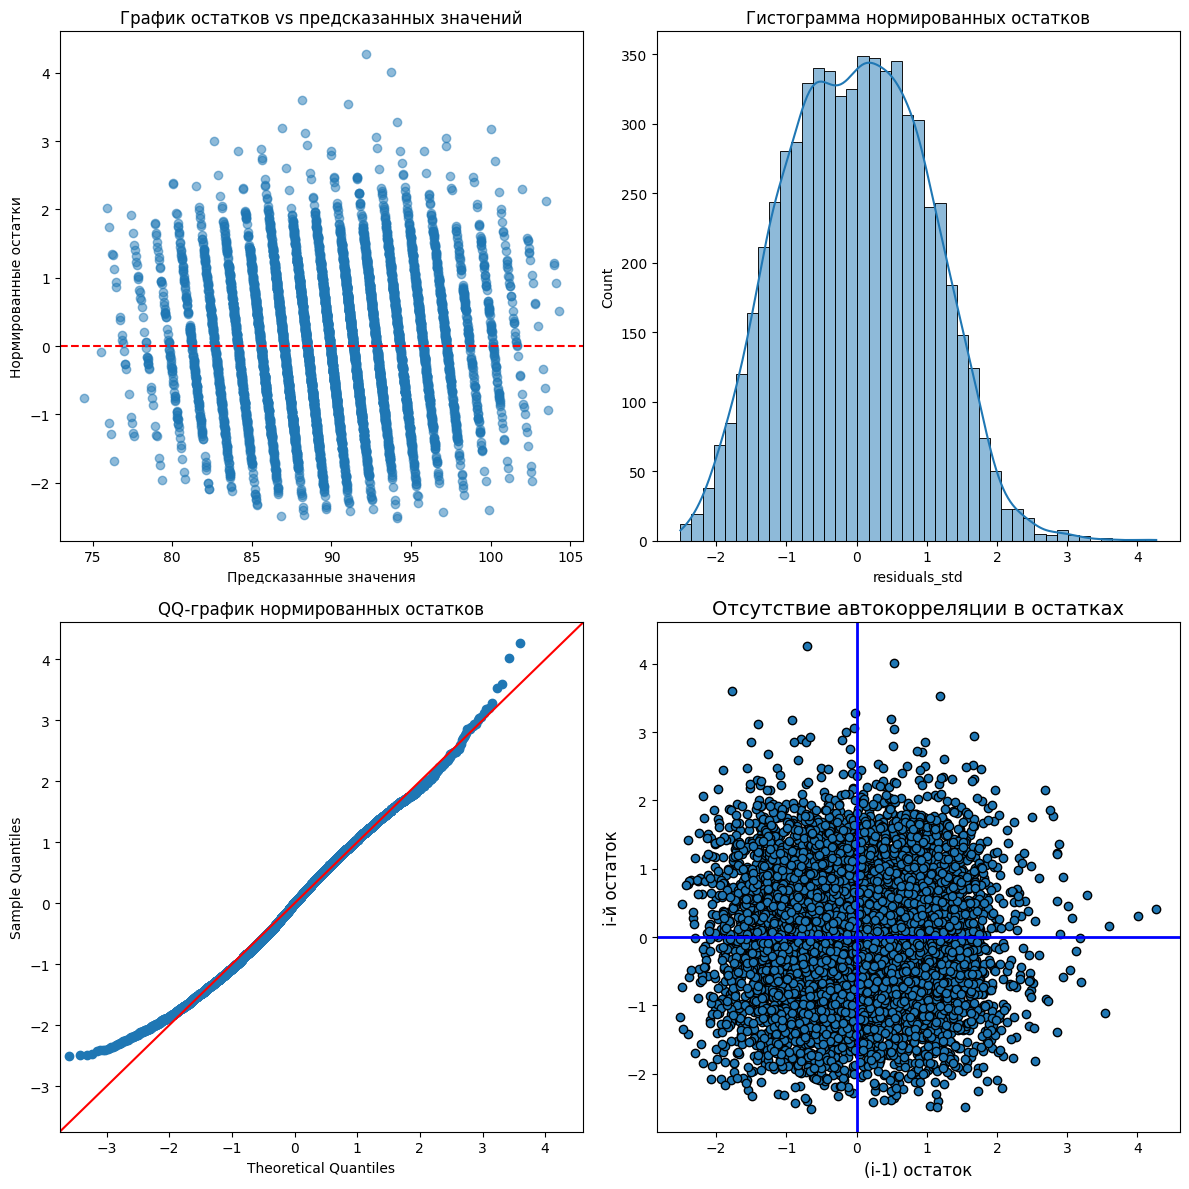

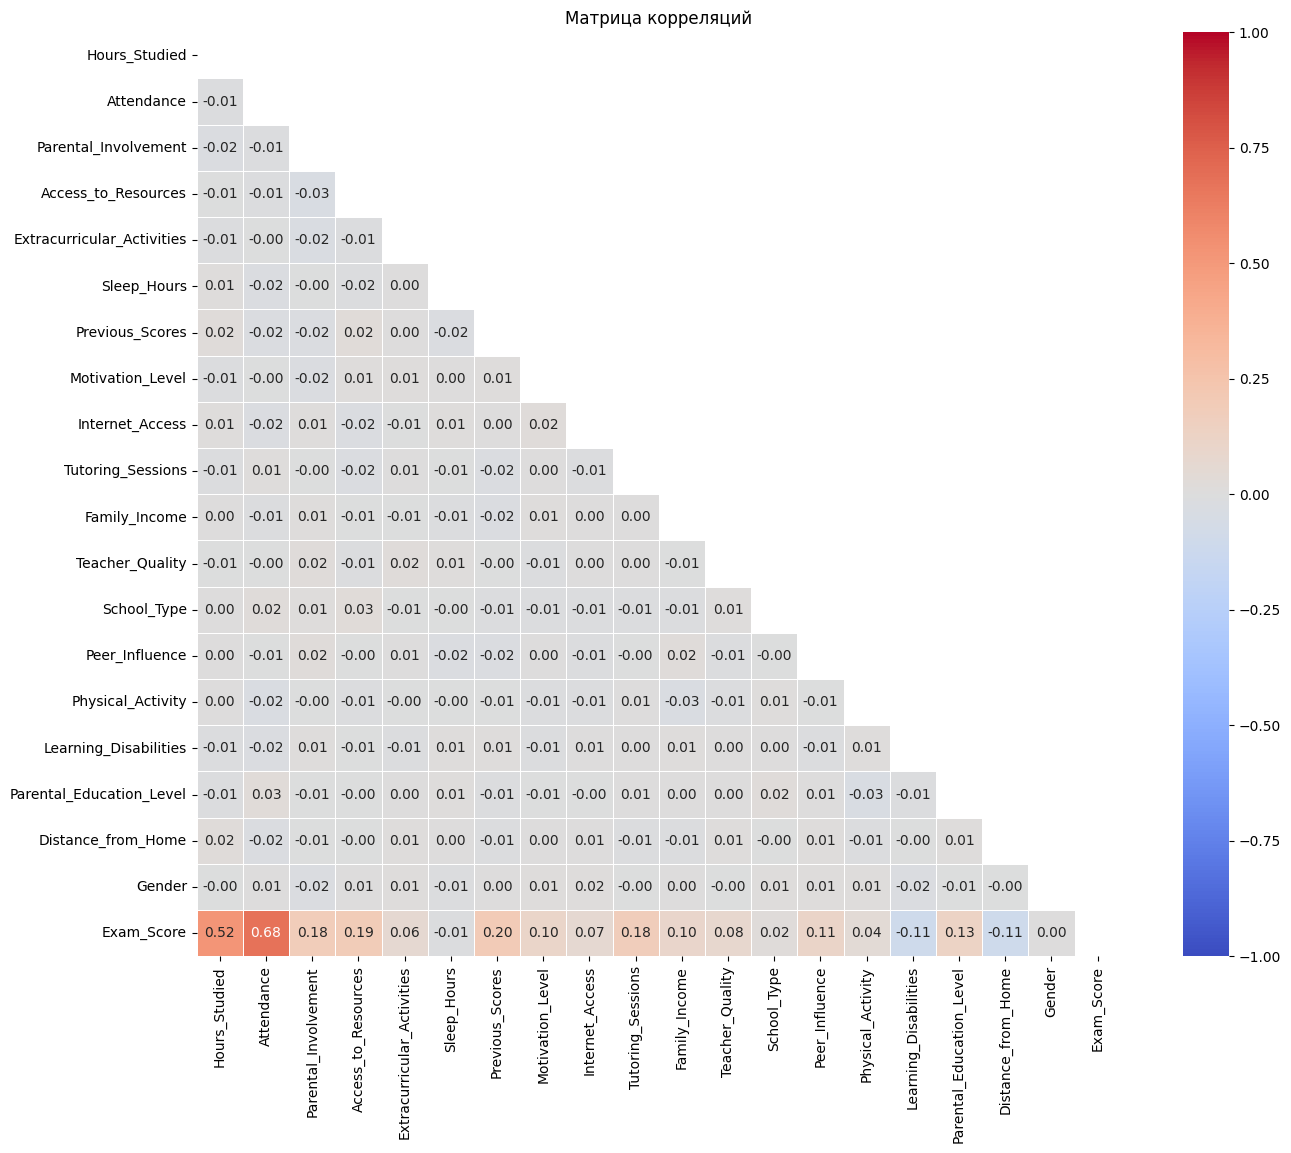

Проверка на мультиколлинеарности:
                       Feature         VIF
0                Hours_Studied   24.606089
1                   Attendance  156.719186
2         Parental_Involvement    4.070215
3          Access_to_Resources    4.118791
4   Extracurricular_Activities    2.562545
5                  Sleep_Hours   24.222000
6              Previous_Scores   38.797292
7             Motivation_Level    2.856963
8              Internet_Access   14.237637
9            Tutoring_Sessions    3.589778
10               Family_Income    2.256568
11             Teacher_Quality    5.270216
12                 School_Type    1.443262
13              Peer_Influence    3.749339
14           Physical_Activity   10.059872
15       Learning_Disabilities    1.129443
16    Parental_Education_Level    1.919601
17          Distance_from_Home    1.570323
18                      Gender    2.377175


c:\Users\krasn\source\repos\SHAD_MTS_24_25\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6322.
  res = hypotest_fun_out(*samples, **kwds)


,test,p_level,a_level,a_calc,a_calc >= a_level,statistic,critical_value,statistic < critical_value,conclusion
0,Shapiro-Wilk test,0.95,0.05,0.0,False,0.994001,,,not gaussian distribution
1,Epps-Pulley test,0.95,0.05,-,-,-,-,False,count more than 1000
2,D'Agostino's K-squared test,0.95,0.05,0.0,False,90.352588,,,not gaussian distribution
3,Anderson-Darling test,0.95,0.05,,,9.601055,0.787,False,not gaussian distribution
4,Kolmogorov–Smirnov test,0.95,0.05,0.00009,False,0.028102,,,not gaussian distribution
5,Lilliefors test,0.95,0.05,0.001,False,0.028393,,,not gaussian distribution
6,Cramér–von Mises test,0.95,0.05,0.000161,False,1.512563,,,not gaussian distribution
7,Chi-squared test,0.95,0.05,1.0,True,-659770159519195987968.0,,,gaussian distribution
8,Jarque–Bera test,0.95,0.05,0.0,False,59.040333,,,not gaussian distribution
9,skewtest,0.95,0.05,0.001239,False,3.229786,,,not gaussian distribution


In [351]:
# Обучим модель и выведем результаты
dt_data, model_data = train_model(df, target=y, feature_names=X, show_results=True, return_norm_tests=True)

### Выводы по модели регрессионного анализа

#### 1. Высокая объясняющая способность модели
- Коэффициент детерминации **\( R^2 = 0.989 \)** показывает, что **98.9% дисперсии** зависимой переменной (`Exam_Score`) объясняется включёнными в модель предикторами.  
- Это свидетельствует о **высокой точности модели**.

#### 2. Значимость предикторов
- Почти все коэффициенты предикторов **значимы на уровне \( p < 0.05 \)**, кроме:
  - `School_Type` (\( p = 0.719 \))
  - `Gender` (\( p = 0.260 \))
- Эти факторы **не оказывают значимого влияния** на итоговый балл экзамена.

#### 3. Статистические тесты
- **Durbin-Watson = 1.994** → Отсутствие автокорреляции остатков.
- **Omnibus = 90.353, Prob(Omnibus) = 0.000** → Остатки не полностью нормальны, также это подтверждается графиком QQplot и различными тестами, но при **6322 наблюдениях** это некритично.
- **Condition Number = 1.44e+03** → Возможные признаки **мультиколлинеарности**, например, при **VIF тестировании** `Attendance` имеет значение 156, но этот фактор значим для нашей модели, после удалении которого возможна ухудшение работы модели.

#### 4. Доработка модели
- Уберем незначимые факторы(`School_Type`,`Gender`).
- Уберем строки, у которых номированная ошибка больше 3.

In [352]:
df2 = df.drop(dt_data[dt_data['residuals_std'] > 3].index)
X2 = X.drop(['Gender', 'School_Type'])

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 3.494e+04
Date:                Wed, 19 Mar 2025   Prob (F-statistic):               0.00
Time:                        23:44:26   Log-Likelihood:                -4542.0
No. Observations:                6311   AIC:                             9120.
Df Residuals:                    6293   BIC:                             9242.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

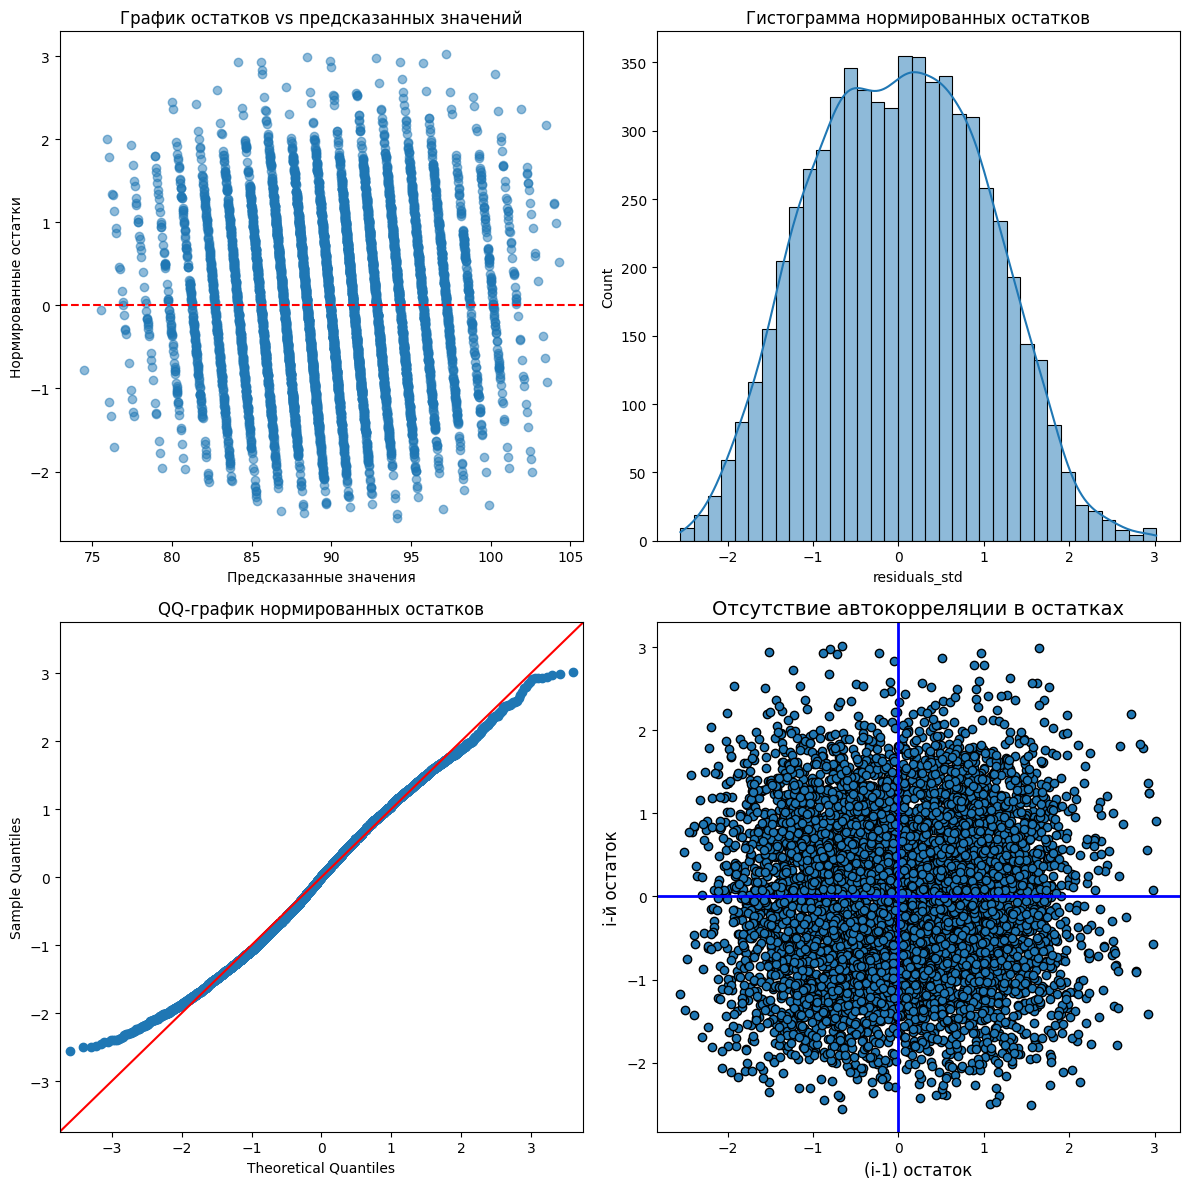

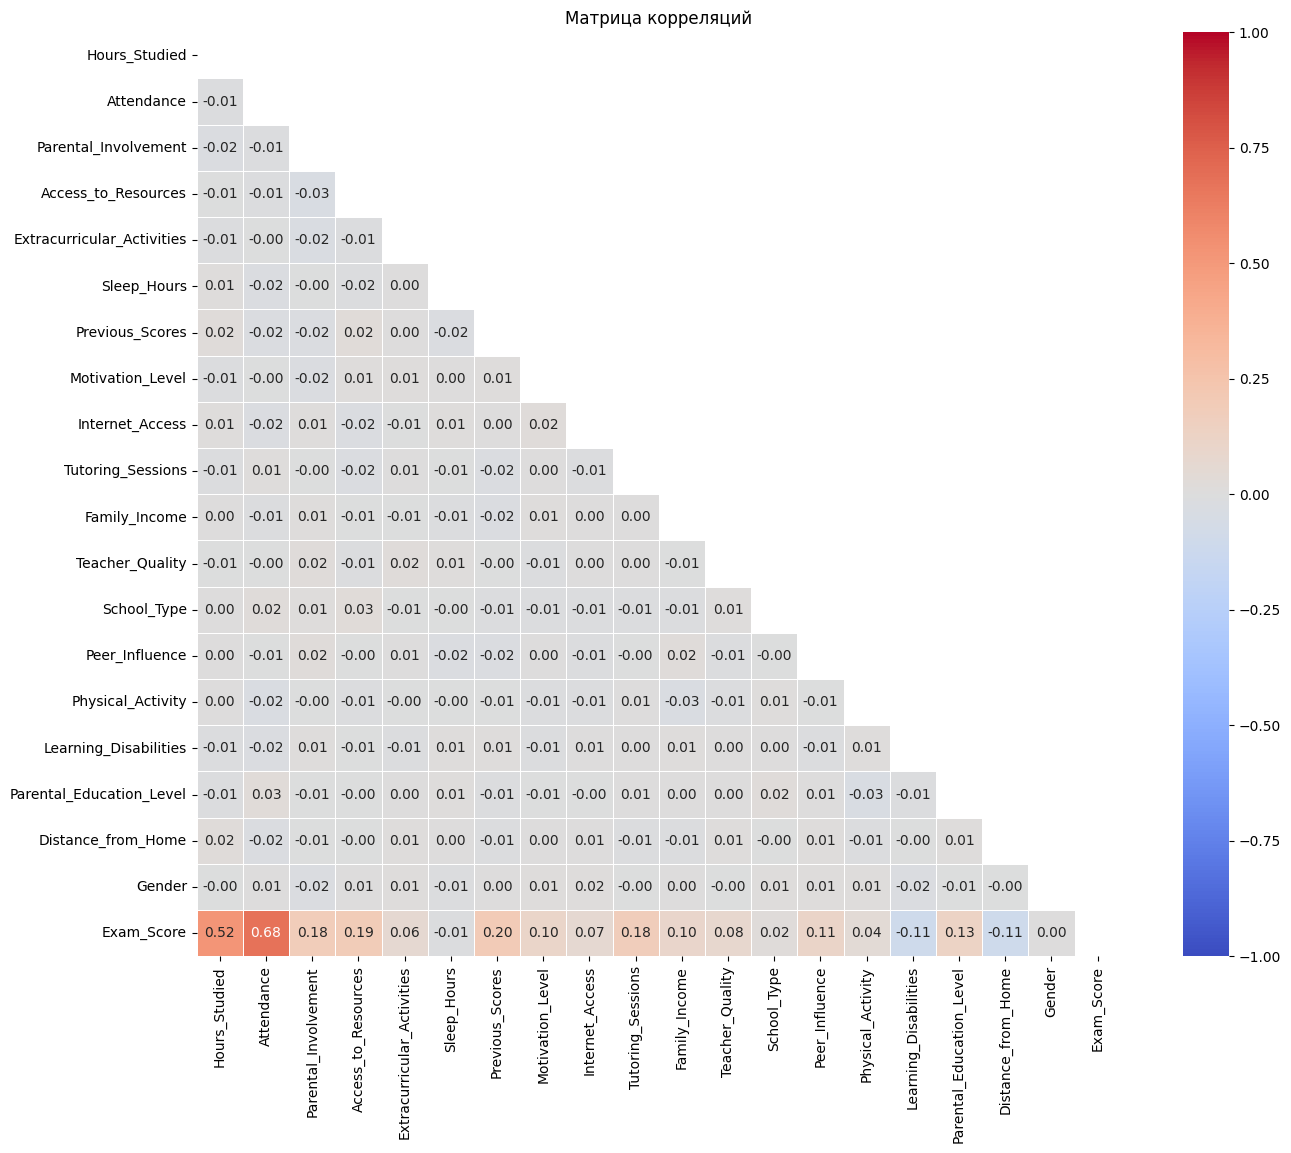

Проверка на мультиколлинеарности:
                       Feature         VIF
0                Hours_Studied   24.597870
1                   Attendance  156.930843
2         Parental_Involvement    4.076204
3          Access_to_Resources    4.118783
4   Extracurricular_Activities    2.562642
5                  Sleep_Hours   24.247399
6              Previous_Scores   38.762697
7             Motivation_Level    2.856352
8              Internet_Access   14.276623
9            Tutoring_Sessions    3.590983
10               Family_Income    2.256205
11             Teacher_Quality    5.268536
12              Peer_Influence    1.002504
13           Physical_Activity    3.752119
14       Learning_Disabilities   10.053658
15    Parental_Education_Level    1.129133
16          Distance_from_Home    1.918578


c:\Users\krasn\source\repos\SHAD_MTS_24_25\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6311.
  res = hypotest_fun_out(*samples, **kwds)


,test,p_level,a_level,a_calc,a_calc >= a_level,statistic,critical_value,statistic < critical_value,conclusion
0,Shapiro-Wilk test,0.95,0.05,0.0,False,0.993471,,,not gaussian distribution
1,Epps-Pulley test,0.95,0.05,-,-,-,-,False,count more than 1000
2,D'Agostino's K-squared test,0.95,0.05,0.0,False,186.738567,,,not gaussian distribution
3,Anderson-Darling test,0.95,0.05,,,10.938451,0.787,False,not gaussian distribution
4,Kolmogorov–Smirnov test,0.95,0.05,0.000097,False,0.028028,,,not gaussian distribution
5,Lilliefors test,0.95,0.05,0.001,False,0.02825,,,not gaussian distribution
6,Cramér–von Mises test,0.95,0.05,0.000047,False,1.747193,,,not gaussian distribution
7,Chi-squared test,0.95,0.05,1.0,True,-11180589710063859400704.0,,,gaussian distribution
8,Jarque–Bera test,0.95,0.05,0.0,False,91.360901,,,not gaussian distribution
9,skewtest,0.95,0.05,0.09642,True,1.662463,,,gaussian distribution


In [353]:
# Обучим модель и выведем результаты
dt_data, model_data = train_model(df2, target=y, feature_names=X2, show_results=True, return_norm_tests=True)

### Выводы

Качество модели не сильно увеличилось при удалении выбросов, значит эти выбросы не сильно влияли нашу модел, и не уменьшилось при удаление некоторых факторов, значит, мы их правильно удалили.

Оставляем коэффициенты и факторы, которые получились в последней модели.